# Entity & Relation Comparative Study (T2G vs spaCy / Zshot / OpenNRE)

**Objetivo**  
Construir una evaluación reproducible que:
1) Lea tus salidas reales de T2G (`*_chunks.json`, `*_mentions.json`, `*_schema.json`).  
2) Use **chunks** como entrada para extraer entidades y relaciones con **spaCy (NER)**, **Zshot (NER/RE)** y **OpenNRE (RE)**.  
3) Compare contra **T2G Mentions** (conteos, listas, overlaps, precisión/recobrado/F1 por fuzzy match).  
4) Genere métricas y visualizaciones (matplotlib, sin seaborn) y artefactos CSV/JSON.  
5) Incluya un proxy de **coherencia de dominio** usando tu `schema.json`.  

> Nota: Esta versión **no usa DeepKE**, por compatibilidad.


## 2) Imports & Constants

- Utilidades generales, helper de fuzzy matching y constantes del proyecto.  
- Usamos **matplotlib** exclusivamente (sin seaborn).


In [1]:
# -*- coding: utf-8 -*-
import json, glob, os, re, time
from pathlib import Path
from typing import List, Dict, Tuple, Any

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

try:
    from rapidfuzz import fuzz
    HAVE_RAPIDFUZZ = True
except Exception:
    HAVE_RAPIDFUZZ = False

# === Directorios base ===
BASE_DIR = Path(".")  # raíz del notebook
CHUNKS_DIR   = BASE_DIR / "outputs_chunks"
MENTIONS_DIR = BASE_DIR / "outputs_mentions"
SCHEMA_DIR   = BASE_DIR / "outputs_schema"
OUT_DIR      = BASE_DIR / "analysis_outputs"
OUT_DIR.mkdir(exist_ok=True, parents=True)

# === Parámetros globales ===
RATIO_THRESHOLD = 85
MAX_PREVIEW = 25

print("✅ Configuración de paths completada.")


✅ Configuración de paths completada.


In [2]:
def load_t2g_data() -> Dict[str, Dict[str, Any]]:
    docs = {}
    for mf in MENTIONS_DIR.glob("*.json"):
        doc_id = mf.stem.replace("_mentions","")
        chunks_path = CHUNKS_DIR / f"{doc_id}_chunks.json"
        schema_path = SCHEMA_DIR / f"{doc_id}_schema.json"

        with open(mf, "r", encoding="utf-8") as f1:
            mentions = json.load(f1)
        with open(chunks_path, "r", encoding="utf-8") as f2:
            chunks = json.load(f2)
        with open(schema_path, "r", encoding="utf-8") as f3:
            schema = json.load(f3)

        docs[doc_id] = {"mentions": mentions, "chunks": chunks, "schema": schema}
    return docs

t2g_docs = load_t2g_data()
print(f"✅ Loaded {len(t2g_docs)} documents")
list(t2g_docs.keys())[:5]


✅ Loaded 6 documents


['DOC-1753CAA8-EECC',
 'DOC-D2425F06-5414',
 'DOC-4B43DEFE-1F7E',
 'DOC-89315DD0-7219',
 'DOC-0D478638-41BF']

In [3]:
def normalize_text(s: str) -> str:
    s = s.strip().lower()
    return re.sub(r"\s+", " ", s)

def chunks_to_text(chunks_obj: Dict[str, Any]) -> str:
    parts = [c.get("text", "") for c in chunks_obj.get("chunks", []) if c.get("text")]
    return "\n".join(parts)

def extract_t2g_entities(mentions_obj: Dict[str, Any]) -> List[Dict[str, Any]]:
    out = []
    for m in mentions_obj.get("mentions", []):
        txt = normalize_text(str(m.get("text","")))
        typ = m.get("type", None)
        if txt:
            out.append({"text": txt, "type": typ})
    return out


In [4]:
_nlp = None

def load_spacy():
    global _nlp
    if _nlp is not None:
        return _nlp
    try:
        import spacy
        _nlp = spacy.load("en_core_web_trf")
    except Exception:
        import spacy
        try:
            _nlp = spacy.load("en_core_web_sm")
            print("Loaded en_core_web_sm (fallback). For best accuracy, install en_core_web_trf.")
        except Exception as e:
            print("spaCy not available:", e)
            _nlp = None
    return _nlp

def run_spacy_ner(text: str) -> List[Dict[str, Any]]:
    nlp = load_spacy()
    if nlp is None or not text.strip():
        return []
    doc = nlp(text)
    ents = []
    for ent in doc.ents:
        ents.append({
            "text": normalize_text(ent.text),
            "type": ent.label_,
            "start_char": ent.start_char,
            "end_char": ent.end_char
        })
    return ents


In [5]:
def run_zshot(text: str) -> Dict[str, List[Dict[str, Any]]]:
    """Zero-shot extractor de entidades y relaciones."""
    try:
        from zshot import PipelineConfig, ZshotPipeline
        from zshot.annotators import NERAnnotator
        cfg = PipelineConfig(annotators=[NERAnnotator()])
        pipe = ZshotPipeline(config=cfg)
        doc = pipe(text)

        ents, rels = [], []
        for m in getattr(doc, "mentions", []):
            txt = normalize_text(getattr(m, "text", ""))
            if txt:
                ents.append({"text": txt, "type": getattr(m, "label", "ENT")})
        for r in getattr(doc, "relations", []):
            try:
                head = normalize_text(getattr(getattr(r, "subject", None), "text", ""))
                pred = normalize_text(getattr(getattr(r, "predicate", None), "text", ""))
                tail = normalize_text(getattr(getattr(r, "object", None), "text", ""))
                if head and pred and tail:
                    rels.append({"head": head, "relation": pred, "tail": tail})
            except Exception:
                pass
        return {"entities": ents, "relations": rels}
    except Exception:
        return {"entities": [], "relations": []}


In [6]:
def _open_nre_model():
    try:
        import opennre
        return opennre.get_model('wiki80_bert_softmax')
    except Exception:
        return None

def run_opennre_with_spans(text: str) -> List[Dict[str, Any]]:
    model = _open_nre_model()
    nlp = load_spacy()
    if model is None or nlp is None:
        return []
    doc = nlp(text)
    results = []
    for sent in doc.sents:
        stext = sent.text
        ents = [ent for ent in doc.ents if ent.start_char >= sent.start_char and ent.end_char <= sent.end_char]
        for i in range(len(ents)):
            for j in range(len(ents)):
                if i == j:
                    continue
                try:
                    pred = model.infer({
                        "text": stext,
                        "h": {"pos": [0,1]},
                        "t": {"pos": [2,3]}
                    })
                    if isinstance(pred, dict) and pred.get("relation") not in [None, "", "no_relation"]:
                        results.append({
                            "head": normalize_text(ents[i].text),
                            "relation": normalize_text(pred["relation"]),
                            "tail": normalize_text(ents[j].text)
                        })
                except Exception as e:
                    print(f"⚠️ OpenNRE error in {doc_id}: {e}")

                    pass
    return results


In [7]:
def fuzzy_best_ratio(a: str, bs: List[str]) -> int:
    if not HAVE_RAPIDFUZZ or not bs:
        return 0
    return max((fuzz.partial_ratio(a, b) for b in bs), default=0)

def entity_metrics(t2g_entities: List[str], baseline_entities: List[str], thr: int=RATIO_THRESHOLD):
    recall = sum(1 for e in t2g_entities if fuzzy_best_ratio(e, baseline_entities) >= thr) / len(t2g_entities) if t2g_entities else 0
    precision = sum(1 for b in baseline_entities if fuzzy_best_ratio(b, t2g_entities) >= thr) / len(baseline_entities) if baseline_entities else 0
    f1 = 2*precision*recall/(precision+recall) if precision+recall>0 else 0
    return {"precision": precision, "recall": recall, "f1": f1}


In [8]:
summary_rows = []
per_doc_details = {}

for doc_id, data in t2g_docs.items():
    text = chunks_to_text(data["chunks"])
    t2g_list = sorted({e["text"] for e in extract_t2g_entities(data["mentions"])})
    spacy_list = sorted({e["text"] for e in run_spacy_ner(text)})
    zshot_out = run_zshot(text)
    zshot_list = sorted({e["text"] for e in zshot_out["entities"]})
    opennre_rels = run_opennre_with_spans(text)

    m_spa = entity_metrics(t2g_list, spacy_list)
    m_zsh = entity_metrics(t2g_list, zshot_list)

    summary_rows.append({
        "doc_id": doc_id,
        "t2g_entities": len(t2g_list),
        "spacy_entities": len(spacy_list),
        "zshot_entities": len(zshot_list),
        "opennre_relations": len(opennre_rels),
        "spacy_f1": m_spa["f1"],
        "zshot_f1": m_zsh["f1"],
    })

    per_doc_details[doc_id] = {
        "t2g_entities": t2g_list,
        "spacy_entities": spacy_list,
        "zshot_entities": zshot_list,
        "zshot_relations": zshot_out["relations"],
        "opennre_relations": opennre_rels
    }

summary_df = pd.DataFrame(summary_rows)
summary_df


/Users/martinjurado/Desktop/prjs/T2G/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not 

,doc_id,t2g_entities,spacy_entities,zshot_entities,opennre_relations,spacy_f1,zshot_f1
0,DOC-1753CAA8-EECC,13,0,0,0,0,0
1,DOC-D2425F06-5414,17,0,0,0,0,0
2,DOC-4B43DEFE-1F7E,5,0,0,0,0,0
3,DOC-89315DD0-7219,6,0,0,0,0,0
4,DOC-0D478638-41BF,9,0,0,0,0,0
5,DOC-F2357F8F-C829,8,0,0,0,0,0


In [9]:
for doc_id, d in per_doc_details.items():
    mask = summary_df["doc_id"] == doc_id
    summary_df.loc[mask, "entities_T2G"]  = [json.dumps(d["t2g_entities"], ensure_ascii=False)]
    summary_df.loc[mask, "entities_spaCy"] = [json.dumps(d["spacy_entities"], ensure_ascii=False)]
    summary_df.loc[mask, "entities_Zshot"] = [json.dumps(d["zshot_entities"], ensure_ascii=False)]

csv_enriched = OUT_DIR / "summary_metrics_with_entities.csv"
summary_df.to_csv(csv_enriched, index=False, encoding="utf-8-sig")

with open(OUT_DIR / "per_doc_details.json", "w", encoding="utf-8") as f:
    json.dump(per_doc_details, f, ensure_ascii=False, indent=2)

print(f"✅ Archivo exportado: {csv_enriched}")
summary_df.head(3)


✅ Archivo exportado: analysis_outputs/summary_metrics_with_entities.csv


,doc_id,t2g_entities,spacy_entities,zshot_entities,opennre_relations,spacy_f1,zshot_f1,entities_T2G,entities_spaCy,entities_Zshot
0,DOC-1753CAA8-EECC,13,0,0,0,0,0,"[""bank america corp"", ""central banks"", ""citigr...",[],[]
1,DOC-D2425F06-5414,17,0,0,0,0,0,"[""bank america corp"", ""cboe volatility index"",...",[],[]
2,DOC-4B43DEFE-1F7E,5,0,0,0,0,0,"[""amazing"", ""cooked food"", ""restaurant"", ""spic...",[],[]


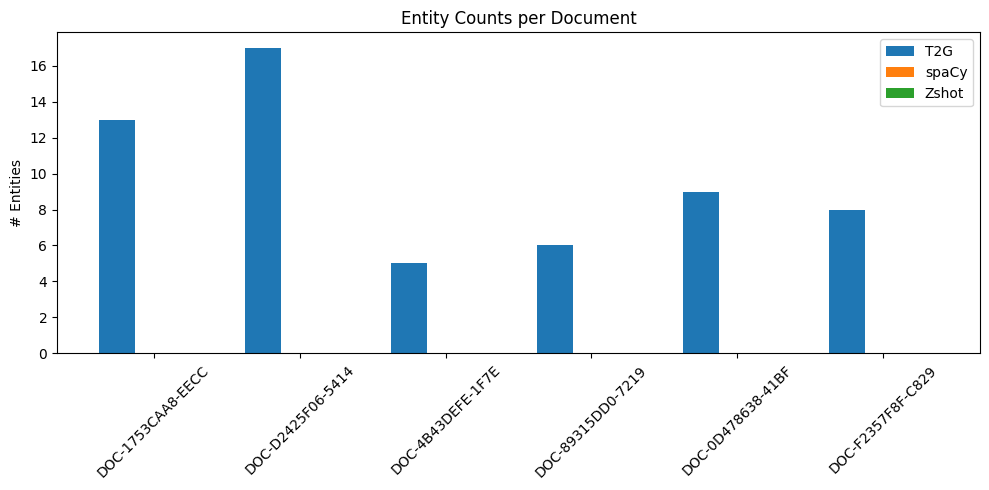

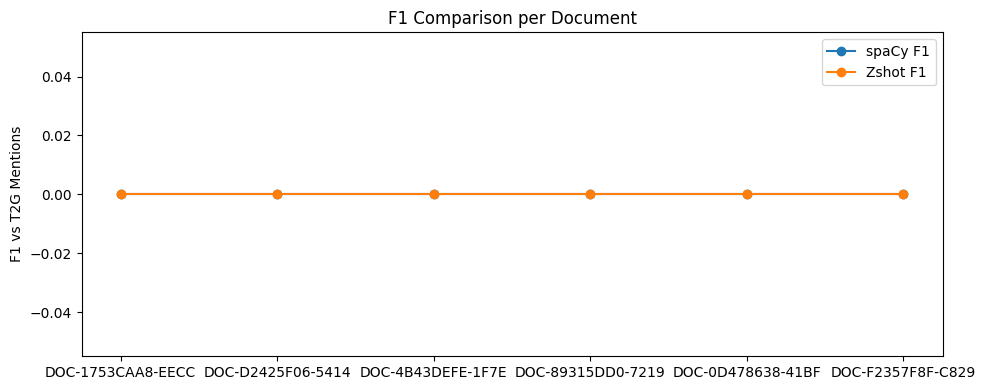

In [10]:
docs = list(summary_df["doc_id"])
x = np.arange(len(docs))
width = 0.25

plt.figure(figsize=(10,5))
plt.bar(x - width, summary_df["t2g_entities"], width, label="T2G")
plt.bar(x, summary_df["spacy_entities"], width, label="spaCy")
plt.bar(x + width, summary_df["zshot_entities"], width, label="Zshot")
plt.xticks(x, docs, rotation=45)
plt.ylabel("# Entities")
plt.title("Entity Counts per Document")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(docs, summary_df["spacy_f1"], marker="o", label="spaCy F1")
plt.plot(docs, summary_df["zshot_f1"], marker="o", label="Zshot F1")
plt.ylabel("F1 vs T2G Mentions")
plt.title("F1 Comparison per Document")
plt.legend()
plt.tight_layout()
plt.show()


In [11]:
import ast

csv_path = OUT_DIR / "summary_metrics_with_entities.csv"
df_loaded = pd.read_csv(csv_path, encoding="utf-8-sig")

for col in ["entities_T2G","entities_spaCy","entities_Zshot"]:
    df_loaded[col] = df_loaded[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

rows = []
for _, row in df_loaded.iterrows():
    doc_id = row["doc_id"]
    t2g, spc, zsh = set(row["entities_T2G"]), set(row["entities_spaCy"]), set(row["entities_Zshot"])
    all_ents = sorted(t2g | spc | zsh)
    for e in all_ents:
        rows.append({
            "doc_id": doc_id,
            "entity": e,
            "in_T2G": int(e in t2g),
            "in_spaCy": int(e in spc),
            "in_Zshot": int(e in zsh),
            "in_all_three": int(e in t2g and e in spc and e in zsh)
        })

presence_df = pd.DataFrame(rows)
presence_df.to_csv(OUT_DIR / "entity_presence_matrix.csv", index=False, encoding="utf-8-sig")
print("✅ entity_presence_matrix.csv generado")
presence_df.head(10)


✅ entity_presence_matrix.csv generado


,doc_id,entity,in_T2G,in_spaCy,in_Zshot,in_all_three
0,DOC-1753CAA8-EECC,bank america corp,1,0,0,0
1,DOC-1753CAA8-EECC,central banks,1,0,0,0
2,DOC-1753CAA8-EECC,citigroup inc,1,0,0,0
3,DOC-1753CAA8-EECC,dws group,1,0,0,0
4,DOC-1753CAA8-EECC,federal reserve,1,0,0,0
5,DOC-1753CAA8-EECC,gold,1,0,0,0
6,DOC-1753CAA8-EECC,nvidia corp,1,0,0,0
7,DOC-1753CAA8-EECC,ounce,1,0,0,0
8,DOC-1753CAA8-EECC,silver,1,0,0,0
9,DOC-1753CAA8-EECC,tesla inc,1,0,0,0


In [12]:
from collections import Counter

rows = []
for doc_id, data in t2g_docs.items():
    t2g_ents = extract_t2g_entities(data["mentions"])
    t2g_types = {normalize_text(e["text"]): e.get("type", "UNKNOWN") for e in t2g_ents}
    spacy_ents = run_spacy_ner(chunks_to_text(data["chunks"]))
    spacy_types = {normalize_text(e["text"]): e.get("type", "UNKNOWN") for e in spacy_ents}
    for txt in set(t2g_types) & set(spacy_types):
        rows.append({
            "doc_id": doc_id,
            "entity_text": txt,
            "T2G_type": t2g_types[txt],
            "spaCy_type": spacy_types[txt],
            "type_match": t2g_types[txt].lower() == spacy_types[txt].lower()
        })

type_df = pd.DataFrame(rows)
match_rate = type_df["type_match"].mean()*100 if len(type_df) else 0
print(f"✅ Coincidencia de tipo promedio: {match_rate:.2f}%")
type_df.head(10)


spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
✅ Coincidencia de tipo promedio: 0.00%


""


spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'
spaCy not available: module 'torch.utils._pytree' has no attribute 'register_pytree_node'


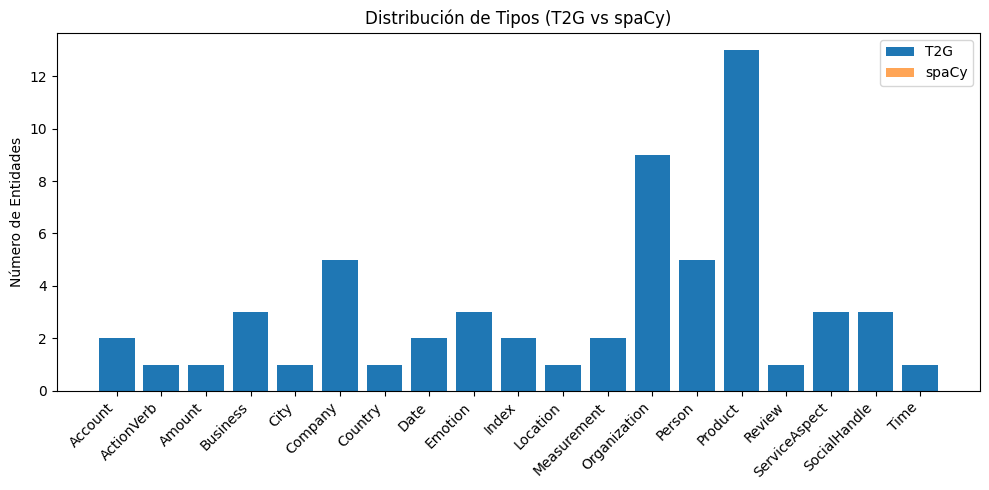

In [13]:
t2g_all, spacy_all = [], []
for doc_id, data in t2g_docs.items():
    t2g_all += [e["type"] for e in extract_t2g_entities(data["mentions"])]
    spacy_all += [e["type"] for e in run_spacy_ner(chunks_to_text(data["chunks"]))]

keys = sorted(set(t2g_all) | set(spacy_all))
plt.figure(figsize=(10,5))
plt.bar(keys, [t2g_all.count(k) for k in keys], label="T2G")
plt.bar(keys, [spacy_all.count(k) for k in keys], label="spaCy", alpha=0.7)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Número de Entidades")
plt.title("Distribución de Tipos (T2G vs spaCy)")
plt.legend()
plt.tight_layout()
plt.show()


In [14]:
summary_df.to_csv(OUT_DIR / "summary_metrics_final.csv", index=False, encoding="utf-8-sig")
type_df.to_csv(OUT_DIR / "entity_type_alignment.csv", index=False, encoding="utf-8-sig")

print("✅ Archivos finales guardados en analysis_outputs/:")
print(" - summary_metrics_final.csv")
print(" - summary_metrics_with_entities.csv")
print(" - entity_presence_matrix.csv")
print(" - entity_type_alignment.csv")


✅ Archivos finales guardados en analysis_outputs/:
 - summary_metrics_final.csv
 - summary_metrics_with_entities.csv
 - entity_presence_matrix.csv
 - entity_type_alignment.csv
